# Phân tích chuỗi thời gian: Mô hình ARIMA vs VAR

Sử dụng dữ liệu **thực** UCI Air Quality (đọc nồng độ chất ô nhiễm theo giờ từ cảm biến tại Ý, tháng 3/2004 – tháng 4/2005).

Nguồn: https://archive.ics.uci.edu/dataset/360/air+quality

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

## 1. Tải & Chuẩn bị dữ liệu thực

In [4]:
# File CSV sử dụng dấu chấm phẩy, số thập phân kiểu châu Âu (dấu phẩy), và dấu chấm trong giờ (18.00.00)
df_raw = pd.read_csv(
    '/kaggle/input/datasets/jhonan/airqualityuci/AirQualityUCI.csv',
    sep=';',
    decimal=',',
    na_values=-200,
)

# Xóa các cột trống thừa và các hàng có toàn bộ giá trị NaN
df_raw = df_raw.drop(columns=[c for c in df_raw.columns if 'Unnamed' in c or c == ''], errors='ignore')
df_raw = df_raw.dropna(how='all').reset_index(drop=True)

# Kết hợp Date + Time thành DatetimeIndex đúng chuẩn (giờ sử dụng dấu chấm: 18.00.00)
df_raw['Datetime'] = pd.to_datetime(
    df_raw['Date'] + ' ' + df_raw['Time'].str.replace('.', ':'),
    format='%d/%m/%Y %H:%M:%S',
)

# Chọn một số chất ô nhiễm chính
cols = ['CO(GT)', 'C6H6(GT)', 'NO2(GT)', 'T']  # CO, Benzene, NO2, Temperature
df = df_raw[['Datetime'] + cols].copy()
df = df.dropna(subset=cols)
df = df.set_index('Datetime')

# Lấy trung bình theo ngày để giảm nhiễu và tăng tốc độ huấn luyện
df = df.resample('D').mean().dropna()

print(f'Shape: {df.shape}')
print(f'Date range: {df.index[0].date()} to {df.index[-1].date()}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Shape: (341, 4)
Date range: 2004-03-10 to 2005-04-04
Columns: ['CO(GT)', 'C6H6(GT)', 'NO2(GT)', 'T']


,CO(GT),C6H6(GT),NO2(GT),T
Datetime,,,,
2004-03-10,1.966667,8.450000,108.833333,12.033333
2004-03-11,2.313636,8.568182,102.863636,9.804545
2004-03-12,2.900000,12.666667,120.285714,11.838095
2004-03-13,2.740909,11.381818,120.500000,13.363636
2004-03-14,2.472727,9.836364,111.681818,16.390909
2004-03-15,3.613636,17.172727,120.909091,17.813636
2004-03-16,2.863636,14.504545,120.863636,19.140909
2004-03-17,3.181818,16.418182,122.681818,19.313636
2004-03-18,2.790909,14.754545,127.272727,18.218182


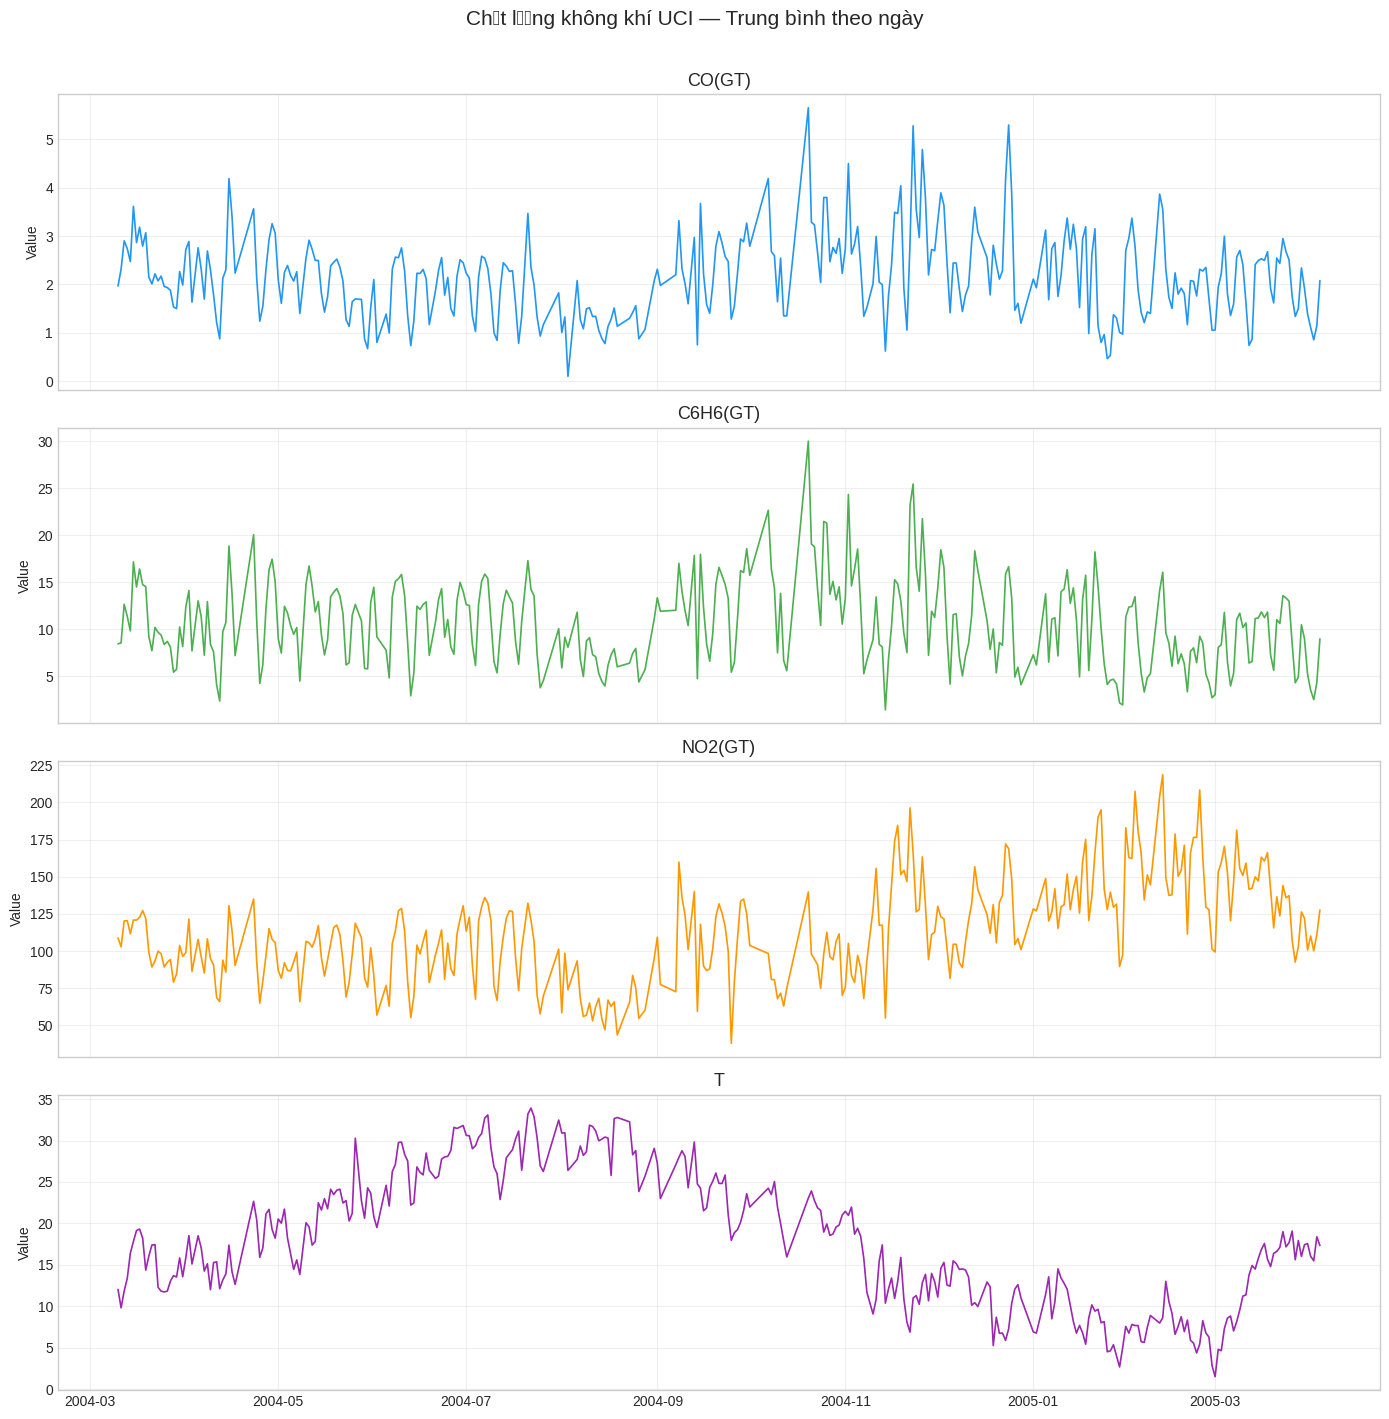

In [5]:
# Plot
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
fig, axes = plt.subplots(len(cols), 1, figsize=(14, 3.5*len(cols)), sharex=True)
for i, col in enumerate(cols):
    axes[i].plot(df.index, df[col], color=colors[i], linewidth=1.2)
    axes[i].set_title(col, fontsize=13)
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)
plt.suptitle('Chất lượng không khí UCI — Trung bình theo ngày', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 2. Chia tập Train-Test

In [6]:
split_ratio = 0.8
split_idx = int(len(df) * split_ratio)

train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]

print(f'Total: {len(df)} days')
print(f'Train: {len(train)} days  ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test:  {len(test)} days  ({test.index[0].date()} → {test.index[-1].date()})')

Total: 341 days
Train: 272 days  (2004-03-10 → 2005-01-23)
Test:  69 days  (2005-01-24 → 2005-04-04)


## 3. Kiểm định tính dừng (ADF)

In [7]:
print(f'{"Variable":<12} {"p-value":>10} {"Status":>16}')
print('-' * 42)
for col in cols:
    p = adfuller(train[col], autolag='AIC')[1]
    status = 'Stationary' if p < 0.05 else 'Non-stationary'
    print(f'{col:<12} {p:>10.4f} {status:>16}')

Variable        p-value           Status
------------------------------------------
CO(GT)           0.0112       Stationary
C6H6(GT)         0.0007       Stationary
NO2(GT)          0.3339   Non-stationary
T                0.9046   Non-stationary


## 4. Mô hình ARIMA

Đơn biến — mỗi chất ô nhiễm được mô hình hóa độc lập.
Tìm kiếm lưới (grid search) trên (p, d, q) để tối thiểu hóa AIC.

In [8]:
arima_preds = {}

for col in cols:
    best_aic = np.inf
    best_order = (1, 1, 1)
    for p in [0, 1, 2, 3]:
        for d in [0, 1]:
            for q in [0, 1, 2, 3]:
                try:
                    fitted = ARIMA(train[col], order=(p, d, q)).fit()
                    if fitted.aic < best_aic:
                        best_aic = fitted.aic
                        best_order = (p, d, q)
                except:
                    pass
    
    fitted = ARIMA(train[col], order=best_order).fit()
    arima_preds[col] = fitted.forecast(steps=len(test)).values
    print(f'{col}: ARIMA{best_order}, AIC={best_aic:.2f}')

CO(GT): ARIMA(3, 1, 3), AIC=619.14
C6H6(GT): ARIMA(0, 1, 2), AIC=1532.69
NO2(GT): ARIMA(2, 1, 3), AIC=2419.92
T: ARIMA(0, 1, 2), AIC=1258.95


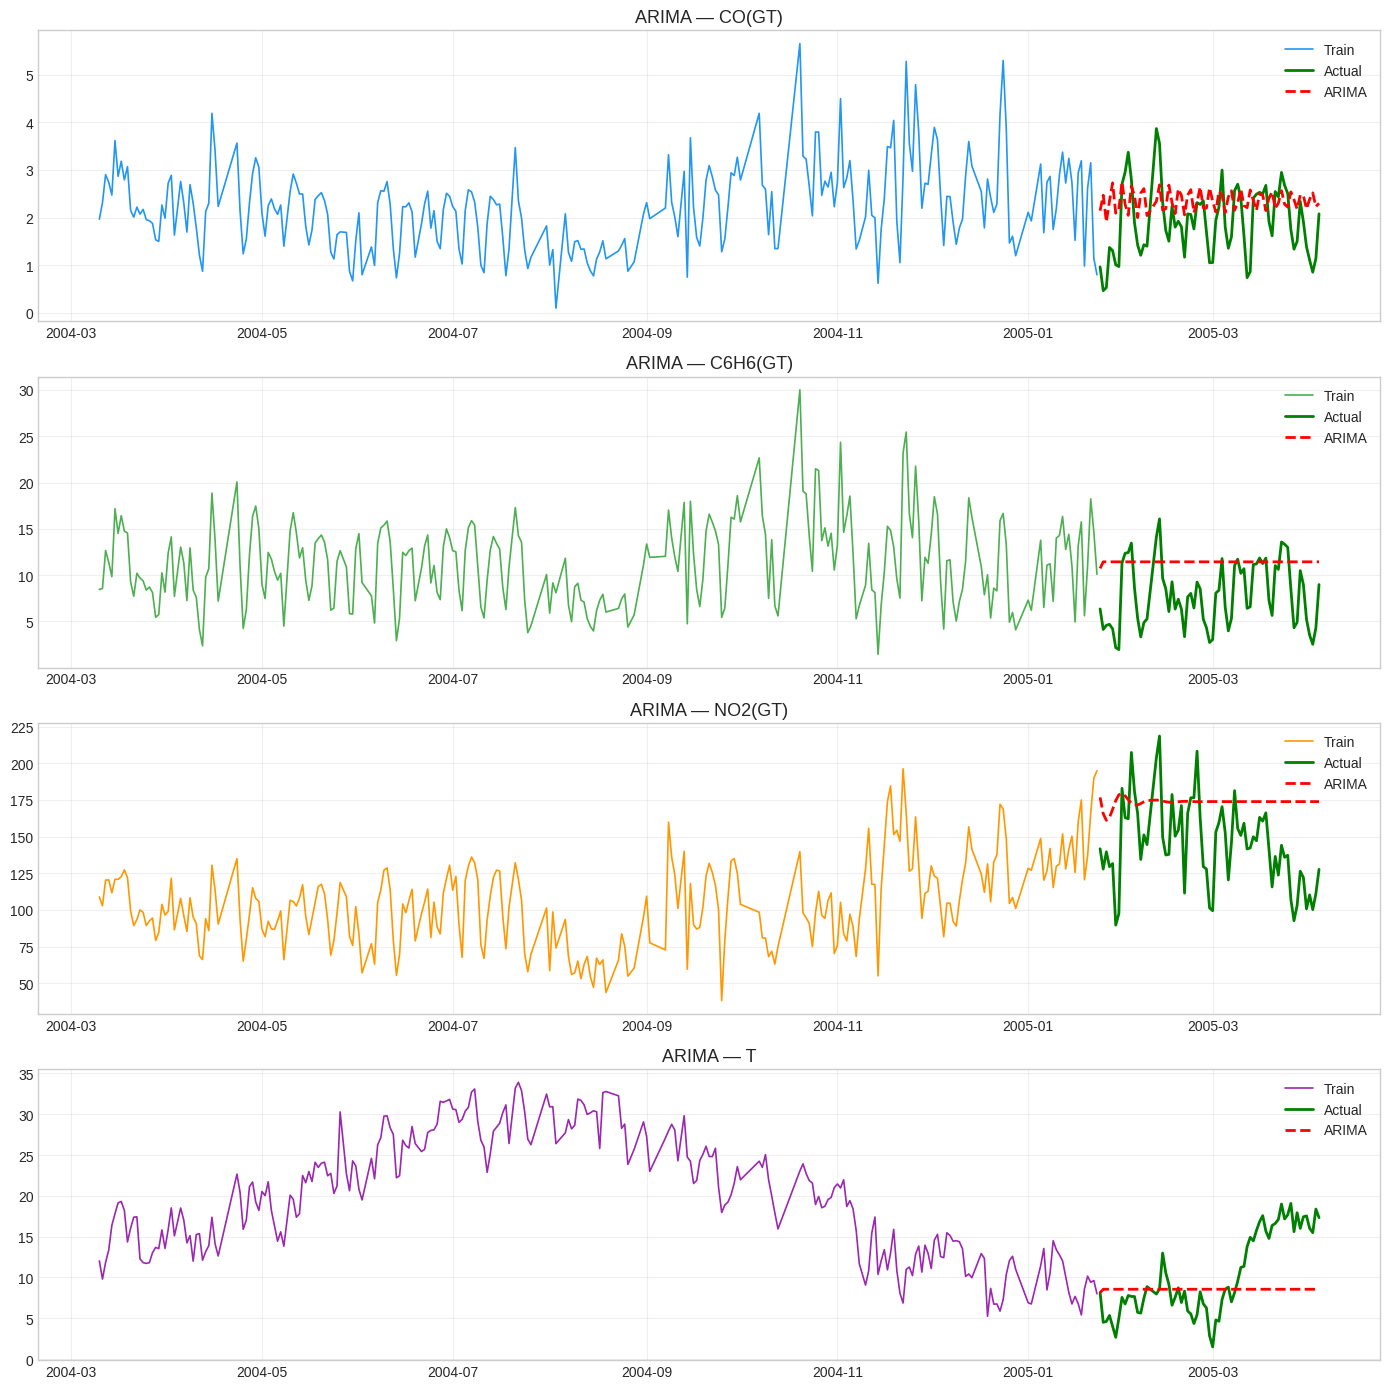

In [9]:
fig, axes = plt.subplots(len(cols), 1, figsize=(14, 3.5*len(cols)))
for i, col in enumerate(cols):
    axes[i].plot(train.index, train[col], label='Train', color=colors[i], linewidth=1.2)
    axes[i].plot(test.index, test[col].values, label='Actual', color='green', linewidth=2)
    axes[i].plot(test.index, arima_preds[col], label='ARIMA', color='red', linewidth=2, linestyle='--')
    axes[i].set_title(f'ARIMA — {col}', fontsize=13)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Mô hình VAR

Đa biến — mô hình hóa tất cả chất ô nhiễm cùng lúc, nắm bắt các tương quan chéo.

In [10]:
# Chọn số bậc trễ tối ưu
lag_aics = {}
for lag in range(1, 16):
    try:
        result = VAR(train).fit(lag)
        lag_aics[lag] = result.aic
    except:
        break

lag_df = pd.DataFrame.from_dict(lag_aics, orient='index', columns=['AIC'])
optimal_lag = lag_df['AIC'].idxmin()
print('Lag AIC values:')
print(lag_df.round(2).to_string())
print(f'\nOptimal lag: {optimal_lag}')

Lag AIC values:
     AIC
1   7.18
2   7.26
3   7.23
4   7.27
5   7.34
6   7.40
7   7.39
8   7.42
9   7.47
10  7.51
11  7.55
12  7.59
13  7.68
14  7.70
15  7.77

Optimal lag: 1


In [11]:
var_fitted = VAR(train).fit(optimal_lag)
var_forecast = var_fitted.forecast(train.values[-optimal_lag:], steps=len(test))

var_preds = {col: var_forecast[:, i] for i, col in enumerate(cols)}
print(f'VAR({optimal_lag}) fitted. AIC={var_fitted.aic:.2f}')

VAR(1) fitted. AIC=7.18


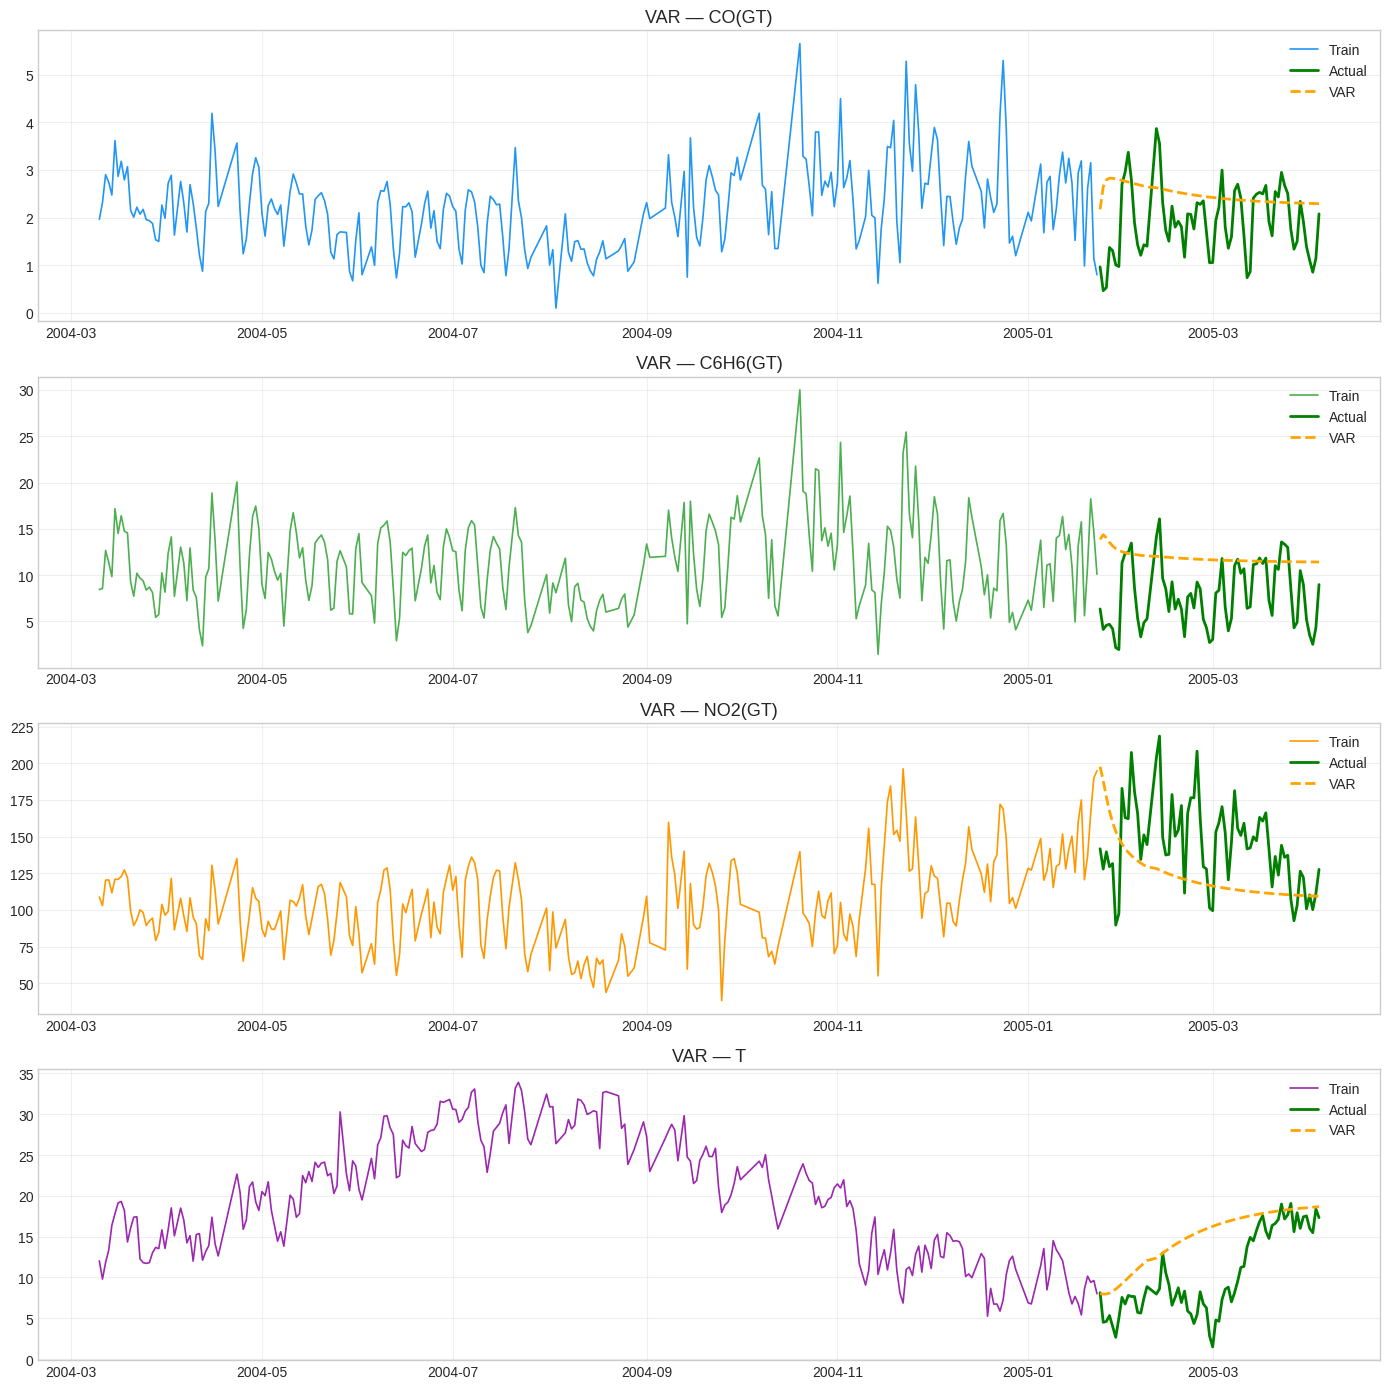

In [12]:
fig, axes = plt.subplots(len(cols), 1, figsize=(14, 3.5*len(cols)))
for i, col in enumerate(cols):
    axes[i].plot(train.index, train[col], label='Train', color=colors[i], linewidth=1.2)
    axes[i].plot(test.index, test[col].values, label='Actual', color='green', linewidth=2)
    axes[i].plot(test.index, var_preds[col], label='VAR', color='orange', linewidth=2, linestyle='--')
    axes[i].set_title(f'VAR — {col}', fontsize=13)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. So sánh trực tiếp: ARIMA vs VAR

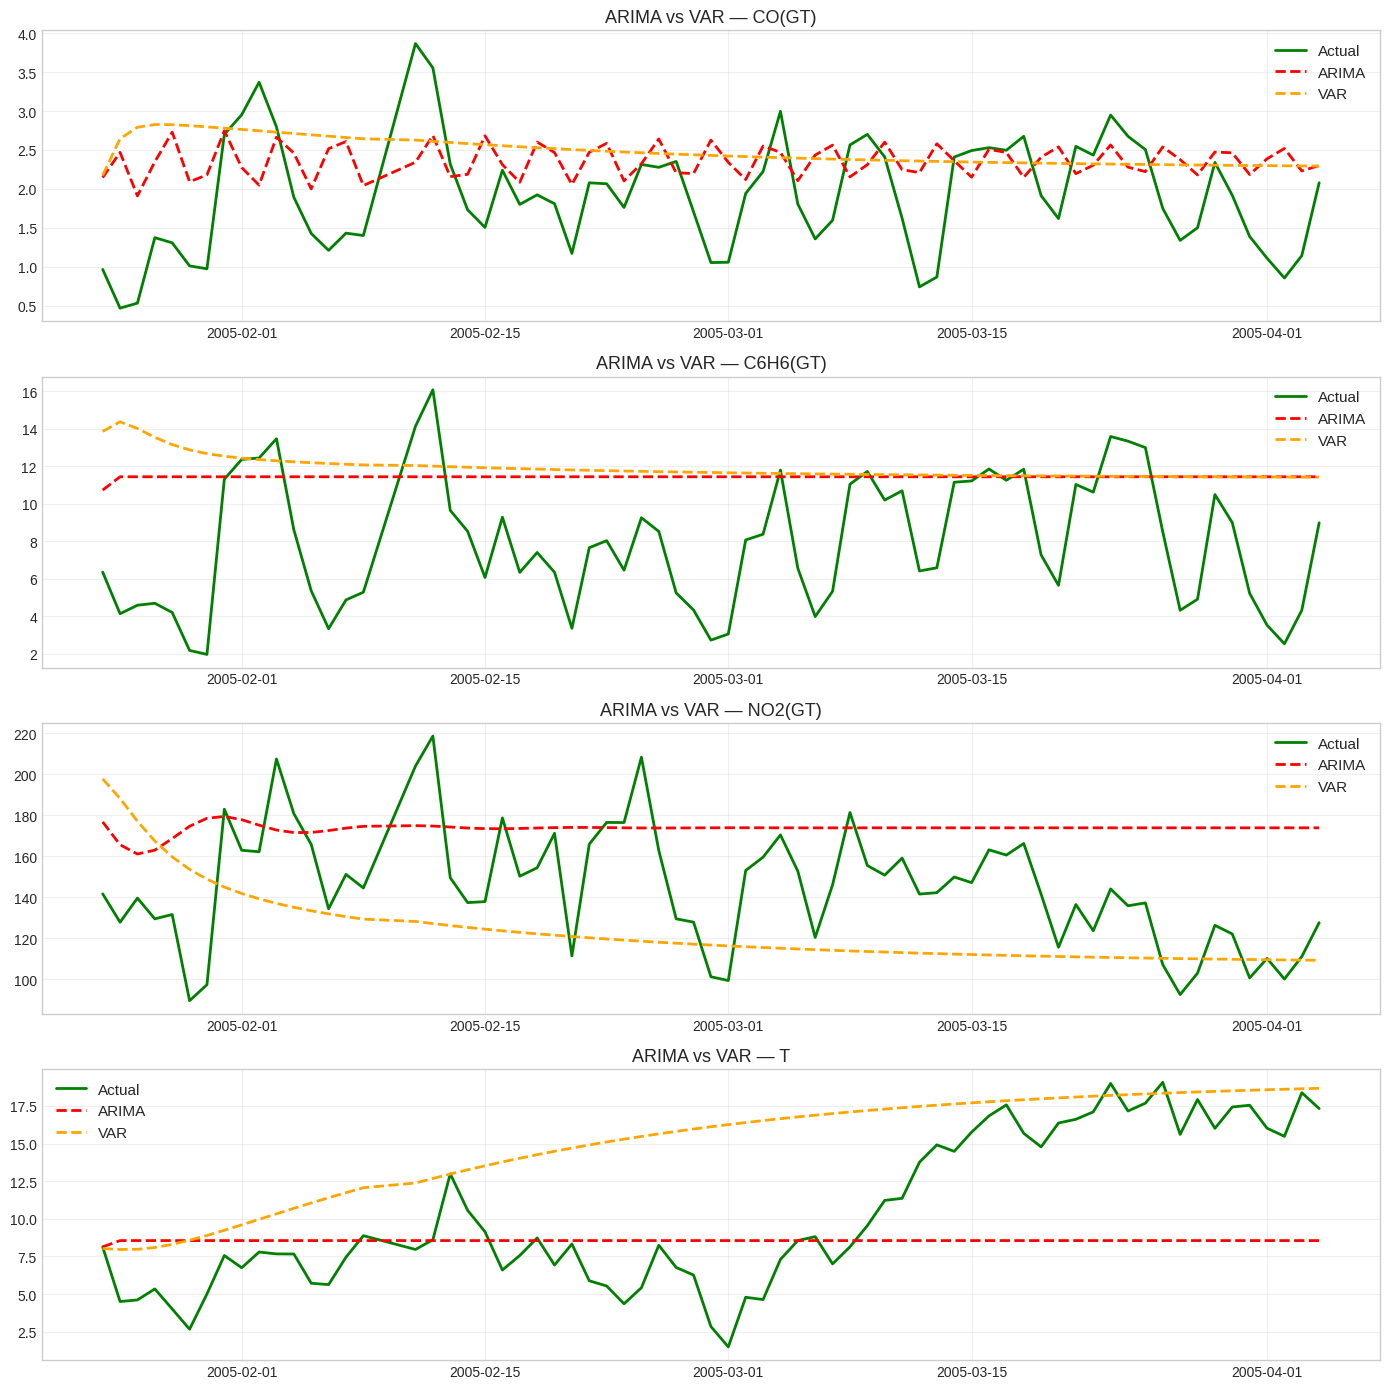

In [13]:
fig, axes = plt.subplots(len(cols), 1, figsize=(14, 3.5*len(cols)))
for i, col in enumerate(cols):
    axes[i].plot(test.index, test[col].values, label='Actual', color='green', linewidth=2)
    axes[i].plot(test.index, arima_preds[col], label='ARIMA', color='red', linewidth=2, linestyle='--')
    axes[i].plot(test.index, var_preds[col], label='VAR', color='orange', linewidth=2, linestyle='--')
    axes[i].set_title(f'ARIMA vs VAR — {col}', fontsize=13)
    axes[i].legend(fontsize=11)
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Các chỉ số đánh giá

| Chỉ số | Ý nghĩa |
|--------|---------|
| **MSE** | Sai số bình phương trung bình |
| **RMSE** | Căn bậc hai MSE (cùng đơn vị với dữ liệu) |
| **MAE** | Sai số tuyệt đối trung bình |
| **MAPE** | Sai số phần trăm tuyệt đối trung bình (%) |

In [14]:
def calc_metrics(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    mse = mean_squared_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    return {
        'MSE': round(mse, 4),
        'RMSE': round(np.sqrt(mse), 4),
        'MAE': round(mean_absolute_error(y_true, y_pred), 4),
        'MAPE (%)': round(mape, 4)
    }

metric_names = ['MSE', 'RMSE', 'MAE', 'MAPE (%)']
arima_metrics = {}
var_metrics = {}

print('=' * 60)
for col in cols:
    actual = test[col].values
    arima_metrics[col] = calc_metrics(actual, arima_preds[col])
    var_metrics[col]   = calc_metrics(actual, var_preds[col])
    
    print(f'\n{col}:')
    print(f'{"Metric":<12} {"ARIMA":>12} {"VAR":>12} {"Better":>10}')
    print('-' * 48)
    for m in metric_names:
        a = arima_metrics[col][m]
        v = var_metrics[col][m]
        better = 'ARIMA' if a < v else 'VAR'
        print(f'{m:<12} {a:>12.4f} {v:>12.4f} {better:>10}')


CO(GT):
Metric              ARIMA          VAR     Better
------------------------------------------------
MSE                0.7247       0.8769      ARIMA
RMSE               0.8513       0.9364      ARIMA
MAE                0.6944       0.7539      ARIMA
MAPE (%)          55.7925      63.0914      ARIMA

C6H6(GT):
Metric              ARIMA          VAR     Better
------------------------------------------------
MSE               24.5722      29.5813      ARIMA
RMSE               4.9570       5.4389      ARIMA
MAE                4.1065       4.4438      ARIMA
MAPE (%)          89.5988      97.7181      ARIMA

NO2(GT):
Metric              ARIMA          VAR     Better
------------------------------------------------
MSE             1662.1499    1546.5154        VAR
RMSE              40.7695      39.3258        VAR
MAE               34.1071      33.1683        VAR
MAPE (%)          27.5846      21.9575        VAR

T:
Metric              ARIMA          VAR     Better
-------------------

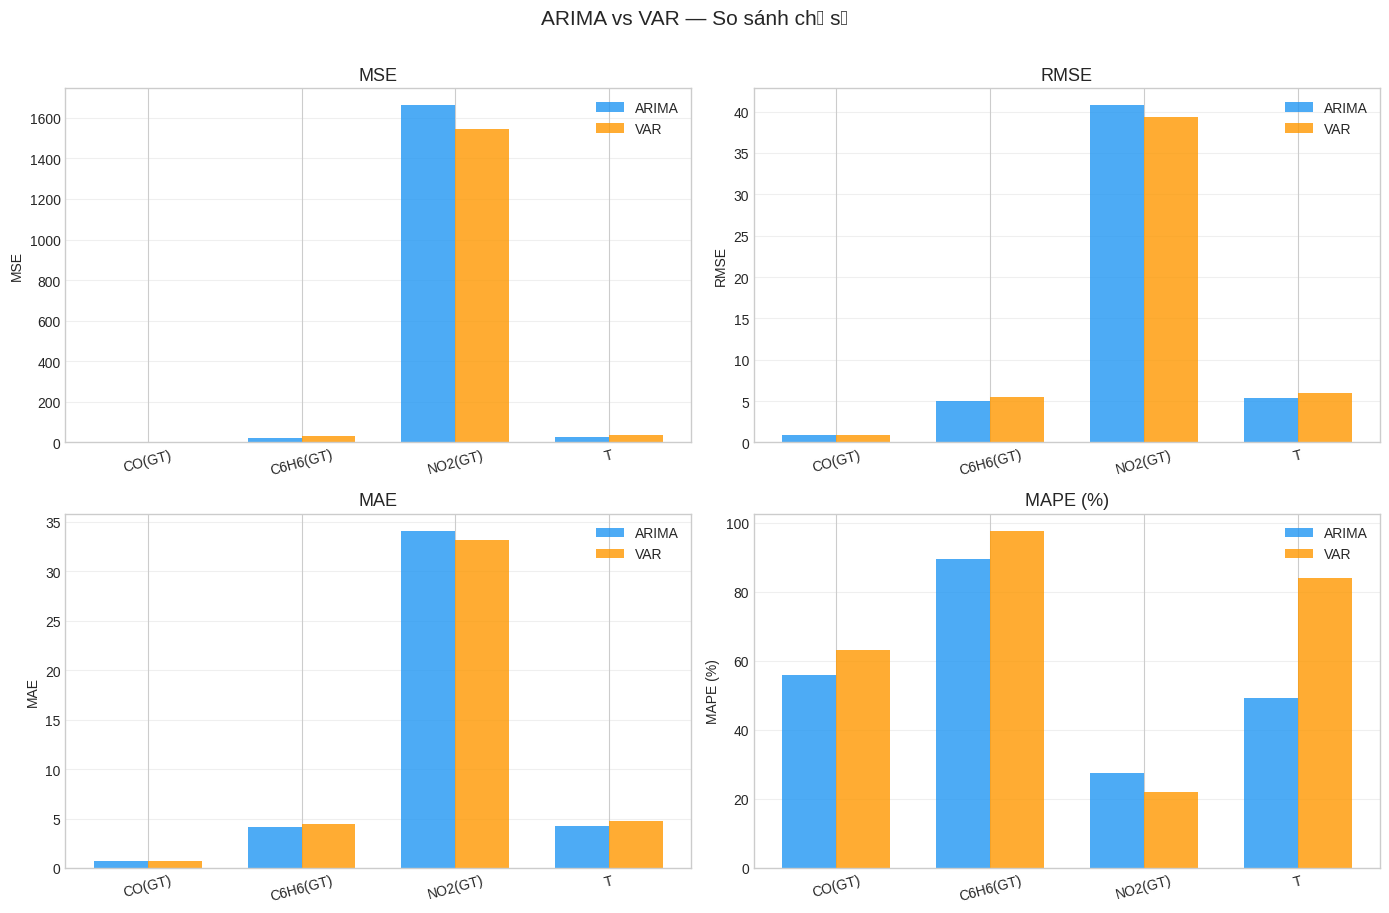

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, metric in enumerate(metric_names):
    x = np.arange(len(cols))
    w = 0.35
    a_vals = [arima_metrics[c][metric] for c in cols]
    v_vals = [var_metrics[c][metric] for c in cols]
    axes[i].bar(x - w/2, a_vals, w, label='ARIMA', color='#2196F3', alpha=0.8)
    axes[i].bar(x + w/2, v_vals, w, label='VAR', color='#FF9800', alpha=0.8)
    axes[i].set_ylabel(metric)
    axes[i].set_title(metric, fontsize=13)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(cols, rotation=15)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3, axis='y')
plt.suptitle('ARIMA vs VAR — So sánh chỉ số', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 8. Tổng kết

In [16]:
print('=' * 60)
print('TỔNG KẾT (trung bình trên tất cả biến)')
print('=' * 60)

arima_wins = 0
var_wins = 0

print(f'\n{"Chỉ số":<12} {"ARIMA (tb)":>15} {"VAR (tb)":>15} {"Tốt hơn":>10}')
print('-' * 55)
for m in metric_names:
    a_avg = np.mean([arima_metrics[c][m] for c in cols])
    v_avg = np.mean([var_metrics[c][m] for c in cols])
    better = 'ARIMA' if a_avg < v_avg else 'VAR'
    if better == 'ARIMA':
        arima_wins += 1
    else:
        var_wins += 1
    print(f'{m:<12} {a_avg:>15.4f} {v_avg:>15.4f} {better:>10}')

print(f'\nARIMA thắng {arima_wins}/{len(metric_names)} chỉ số')
print(f'VAR thắng   {var_wins}/{len(metric_names)} chỉ số')
if arima_wins > var_wins:
    print('\n=> ARIMA hoạt động tốt hơn tổng thể.')
elif var_wins > arima_wins:
    print('\n=> VAR hoạt động tốt hơn tổng thể.')
else:
    print('\n=> Cả hai mô hình hoạt động tương đương.')

TỔNG KẾT (trung bình trên tất cả biến)

Chỉ số            ARIMA (tb)        VAR (tb)    Tốt hơn
-------------------------------------------------------
MSE                 428.9337        403.0356        VAR
RMSE                 12.9741         12.9079        VAR
MAE                  10.7829         10.7714        VAR
MAPE (%)             55.5316         66.6850      ARIMA

ARIMA thắng 1/4 chỉ số
VAR thắng   3/4 chỉ số

=> VAR hoạt động tốt hơn tổng thể.


## 10. Những điểm chính

| | ARIMA | VAR |
|---|---|---|
| **Kiểu** | Đơn biến | Đa biến |
| **Nắm bắt tương quan chéo** | Không | Có |
| **Tham số** | (p, d, q) cho mỗi chuỗi | Số bậc trễ cho tất cả chuỗi |
| **Phù hợp nhất cho** | Chuỗi độc lập | Chuỗi có tương quan |

- **ARIMA**: mỗi chất ô nhiễm được mô hình hóa độc lập; tốt khi chuỗi có động lực riêng mạnh.
- **VAR**: nắm bắt cách các chất ô nhiễm ảnh hưởng lẫn nhau (ví dụ: CO và NO₂ đều đến từ khí thải giao thông); có thể hưởng lợi từ các mẫu chung nhưng cũng rủi ro nhiễu từ các tương quan yếu.